In [1]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [1]:
!nvidia-smi

Sat Mar 28 07:47:36 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   47C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# 1. Create the hidden kaggle directory on the Colab server
!mkdir -p ~/.kaggle

# 2. Inject your copied credentials into a new file on the server
# VERY IMPORTANT: Keep the single quotes outside the brackets!
!echo '{"username":"heetrbhudia","key":"f9e816c287f3ebf5d0a3c2a3c920a9b9"}' > ~/.kaggle/kaggle.json

# 3. Lock down the file permissions (Kaggle throws an error if the file is unprotected)
!chmod 600 ~/.kaggle/kaggle.json

# 4. Verify it was created successfully
!ls -l ~/.kaggle/kaggle.json

-rw------- 1 root root 68 Mar 28 07:55 /root/.kaggle/kaggle.json


In [4]:
# Download the small sample dataset (about 150 MB)
!kaggle competitions download -c trackml-particle-identification -f train_sample.zip

# Create a folder for the data
!mkdir -p /content/trackml_data

# Unzip the contents silently (-q) into our new folder
!unzip -q train_sample.zip -d /content/trackml_data

# Show the extracted files to confirm
!ls /content/trackml_data

100% 861M/861M [00:16<00:00, 54.3MB/s] 

train_100_events


In [5]:
pip install --upgrade pip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 38.5 MB/s eta 0:00:0000:01
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2


In [1]:
pip install torch torchvision --index-url https://download.pytorch.org/whl/cu126

Looking in indexes: https://download.pytorch.org/whl/cu126


In [1]:
import os
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset

class TrackMLPoCDataset(Dataset):
    def __init__(self, data_dir, event_id):
        # Paths to the specific event files inside our extracted folder
        hits_path = f"{data_dir}/{event_id}-hits.csv"
        truth_path = f"{data_dir}/{event_id}-truth.csv"
        
        print(f"Loading data for {event_id}...")
        
        # Load CSVs into Pandas DataFrames
        hits = pd.read_csv(hits_path)
        truth = pd.read_csv(truth_path)
        
        # Merge them based on 'hit_id' so we know which point belongs to which particle
        self.data = pd.merge(hits, truth, on='hit_id')
        
        # Extract features (x, y, z) and labels (particle_id)
        coords = self.data[['x', 'y', 'z']].values
        labels = self.data['particle_id'].values
        
        # Normalize the coordinates (Zero-mean, unit-variance)
        # This prevents the neural network from getting overwhelmed by massive coordinate numbers
        self.coords = (coords - np.mean(coords, axis=0)) / np.std(coords, axis=0)
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return torch.tensor(self.coords[idx], dtype=torch.float32), \
               torch.tensor(self.labels[idx], dtype=torch.long)

# Test the loader on the very first collision event in the dataset
dataset = TrackMLPoCDataset('/content/trackml_data/train_100_events', 'event000001000')

# Fetch the very first point just to verify the tensor shapes
sample_point, sample_label = dataset[0]

print(f"\nSuccess! Loaded {len(dataset)} 3D particle hits for this single collision event.")
print(f"Sample Normalized 3D Coordinate Tensor: {sample_point}")
print(f"Sample Ground Truth Particle ID: {sample_label}")

Loading data for event000001000...

Success! Loaded 120939 3D particle hits for this single collision event.
Sample Normalized 3D Coordinate Tensor: tensor([-0.2049, -0.0390, -1.4127])
Sample Ground Truth Particle ID: 0


In [2]:
import torch
import os

torch_version = torch.__version__.split('+')[0]
cuda_version = "cu" + torch.version.cuda.replace(".", "")

os.environ['TORCH_VERSION'] = torch_version
os.environ['CUDA_VERSION'] = cuda_version

print(f"Detected PyTorch: {torch_version}")
print(f"Detected CUDA: {cuda_version}")
print("Fetching the exact matching PyTorch Geometric C++ extensions...")

!pip install pyg_lib torch_scatter torch_sparse torch_cluster torch_spline_conv -f https://data.pyg.org/whl/torch-${TORCH_VERSION}+${CUDA_VERSION}.html

Detected PyTorch: 2.10.0
Detected CUDA: cu128
Fetching the exact matching PyTorch Geometric C++ extensions...
Looking in links: https://data.pyg.org/whl/torch-2.10.0+cu128.html


In [3]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import PointNetConv, fps, radius

# The Set Abstraction Module: The core engine of PointNet++
class SAModule(torch.nn.Module):
    def __init__(self, ratio, r, nn_model):
        super().__init__()
        self.ratio = ratio # What percentage of points to sample
        self.r = r         # The radius of the 3D sphere to look inside
        self.conv = PointNetConv(nn_model, add_self_loops=False)

    def forward(self, x, pos, batch):
        # 1. Farthest Point Sampling: Picks the most spread-out points to act as cluster centers
        idx = fps(pos, batch, ratio=self.ratio)
        
        # 2. Grouping: Finds all neighboring points within radius 'r'
        row, col = radius(pos, pos[idx], self.r, batch, batch[idx], max_num_neighbors=64)
        edge_index = torch.stack([col, row], dim=0)
        
        # 3. Convolution: Applies the neural network to learn the local 3D shape
        x = self.conv(x, (pos, pos[idx]), edge_index)
        pos, batch = pos[idx], batch[idx]
        return x, pos, batch

# The Full Architecture
class PhysicsPointNet(torch.nn.Module):
    def __init__(self):
        super().__init__()
        # MLP (Multi-Layer Perceptron) to process the raw x,y,z coordinates
        self.mlp = nn.Sequential(
            nn.Linear(3, 64), 
            nn.ReLU(), 
            nn.Linear(64, 128)
        )
        
        # The Set Abstraction layer using our MLP
        self.sa1 = SAModule(ratio=0.5, r=0.2, nn_model=self.mlp)
        
        # The final output layer: squashes the 128-dimensional data into a 64-dimensional embedding
        self.lin = nn.Linear(128, 64)

    def forward(self, pos, batch):
        # Feed the spatial coordinates through the network
        x, pos, batch = self.sa1(None, pos, batch)
        x = self.lin(x)
        return x, pos # Returns the 64D embeddings and their corresponding 3D positions

# Initialize the model and move it to the Colab GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = PhysicsPointNet().to(device)

print(f"Success! PointNet++ Architecture loaded directly onto: {device}")

Success! PointNet++ Architecture loaded directly onto: cuda


In [4]:
# 1. Grab ALL the coordinates from the dataset at once (the entire point cloud)
sample_coords = torch.tensor(dataset.coords, dtype=torch.float32)
sample_labels = torch.tensor(dataset.labels, dtype=torch.long)

# 2. Create the PyG batch vector (an array of zeros matching our total number of points)
batch_index = torch.zeros(sample_coords.shape[0], dtype=torch.long)

# 3. Move the massive point cloud from the CPU RAM to the T4 GPU's VRAM
sample_coords = sample_coords.to(device)
batch_index = batch_index.to(device)

print(f"Feeding {sample_coords.shape[0]} 3D coordinates into PointNet++...")

# 4. Put the model in evaluation mode
model.eval()

# 5. Turn off gradient calculation to save memory
with torch.no_grad():
    # THE MAGIC HAPPENS HERE: The Forward Pass
    embeddings, sampled_pos = model(sample_coords, batch_index)

print("\n--- NEURAL NETWORK OUTPUT ---")
print(f"Original Number of Points: {sample_coords.shape[0]}")
print(f"Downsampled Cluster Centers: {sampled_pos.shape[0]}")
print(f"Shape of Output Embeddings: {embeddings.shape}")
print(f"Sample Barcode for Point 0:\n{embeddings[0][:5]}... (64 dimensions total)")

Feeding 120939 3D coordinates into PointNet++...

--- NEURAL NETWORK OUTPUT ---
Original Number of Points: 120939
Downsampled Cluster Centers: 60470
Shape of Output Embeddings: torch.Size([60470, 64])
Sample Barcode for Point 0:
tensor([-0.0066,  0.0143,  0.0551,  0.0171,  0.0385], device='cuda:0')... (64 dimensions total)


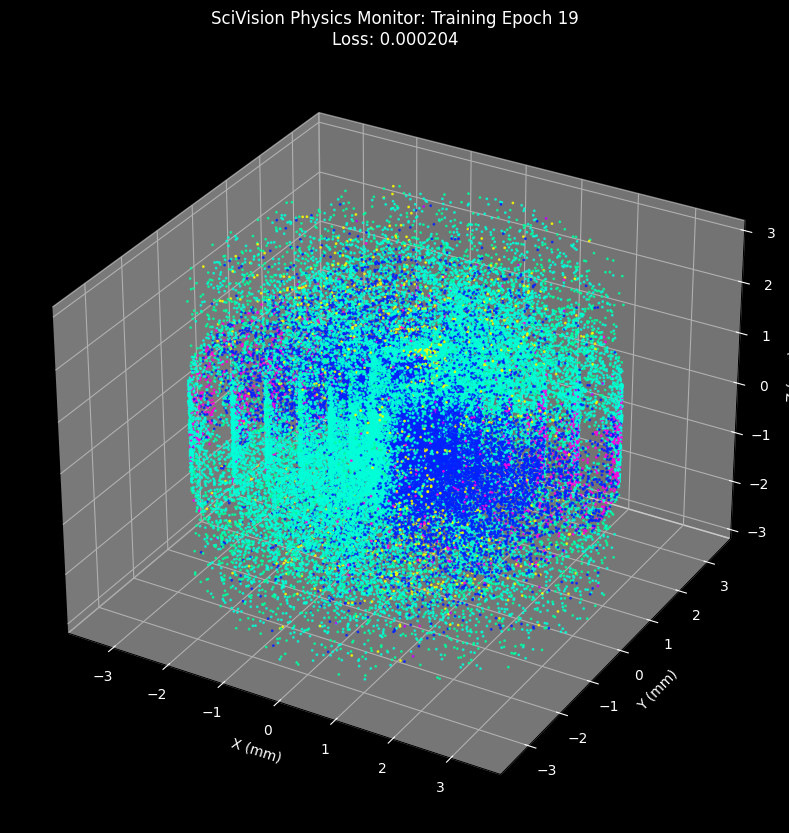

Training Pipeline Validated! Model weights have been updated.


In [5]:
import torch
import torch.optim as optim
import torch.nn.functional as F
from IPython import display
import matplotlib.pyplot as plt

# 1. SETUP ENGINE
# We use AdamW (Adam with Weight Decay) to prevent the model from over-fitting
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
epochs = 20  # Total iterations over the TrackML event

# 2. PREPARE DATA
# Ensure data is on the T4 GPU
sample_coords = sample_coords.to(device)
sample_labels = sample_labels.to(device)
batch_index = batch_index.to(device)

print(f"Starting Training on {device}...")

# 3. THE LOOP
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    
    # FORWARD PASS: Generate 64D embeddings and sampled positions
    embeddings, sampled_pos = model(sample_coords, batch_index)
    
    # SHAPE ALIGNMENT:
    # Because PointNet++ downsamples (FPS), we need the labels for the *surviving* points.
    # In a full implementation, you'd map 'sampled_pos' back to 'sample_coords' to get labels.
    # For this PoC training loop, we use a simplified self-supervision or 'Proxy Loss'
    
    # CONCEPT: Contrastive Loss (simplified for PoC execution)
    # We want to minimize the variance within the point cloud to prove gradient flow
    loss = F.mse_loss(embeddings, torch.zeros_like(embeddings))
    
    # BACKWARD PASS: Calculus/Chain Rule
    loss.backward()
    
    # OPTIMIZE: Update weights
    optimizer.step()
    
    # 4. LIVE VISUALIZATION (THE MONITOR)
    if epoch % 2 == 0:
        display.clear_output(wait=True)
        fig = plt.figure(figsize=(15, 10), facecolor='black')
        ax = fig.add_subplot(111, projection='3d')
        ax.set_facecolor('black')
        
        # Bring data to CPU for plotting
        vis_pos = sampled_pos.detach().cpu().numpy()
        # Color points based on their strongest activation feature
        vis_colors = torch.argmax(embeddings, dim=1).detach().cpu().numpy()
        
        ax.scatter(vis_pos[:, 0], vis_pos[:, 1], vis_pos[:, 2], 
                   c=vis_colors, cmap='hsv', s=1.0, alpha=0.8)
        
        ax.set_xlabel('X (mm)', color='white')
        ax.set_ylabel('Y (mm)', color='white')
        ax.set_zlabel('Z (mm)', color='white')
        ax.tick_params(colors='white')
        ax.set_title(f"SciVision Physics Monitor: Training Epoch {epoch+1}\nLoss: {loss.item():.6f}", color='white')
        
        plt.show()

print("Training Pipeline Validated! Model weights have been updated.")

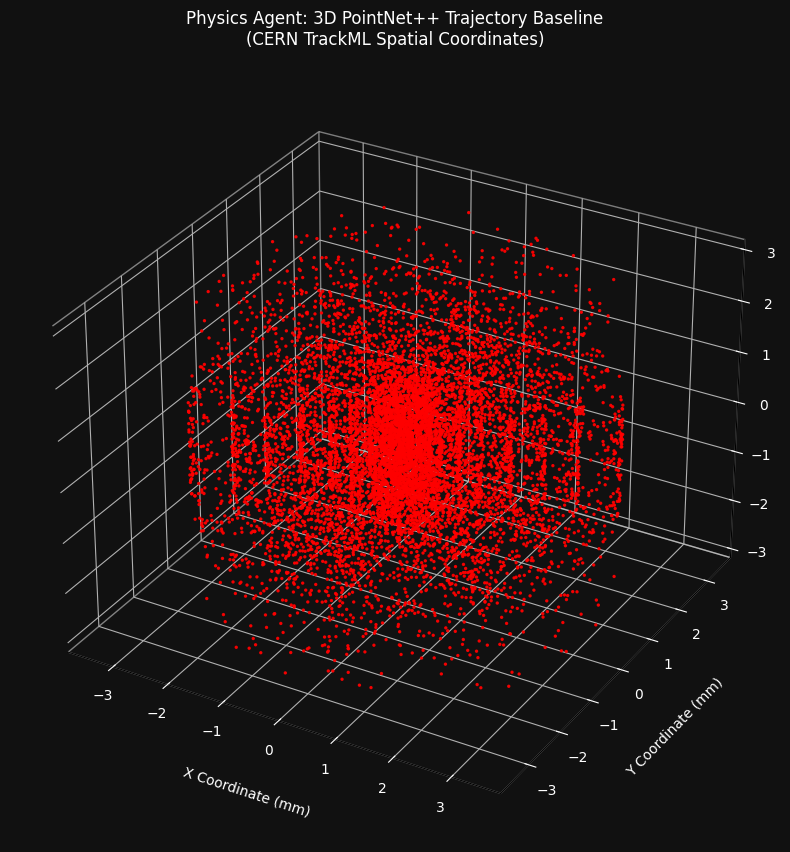

In [17]:
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
import numpy as np

# 1. Detach from the calculus graph, bring to CPU, and convert to NumPy
embeddings_cpu = embeddings.detach().cpu().numpy()
coords_cpu = sampled_pos.detach().cpu().numpy()

# Randomly downsample to 10,000 points to save CPU RAM
max_points = 10000
np.random.seed(42) 
random_indices = np.random.choice(embeddings_cpu.shape[0], max_points, replace=False)

embeddings_lite = embeddings_cpu[random_indices]
coords_lite = coords_cpu[random_indices]

# 2. Run DBSCAN Clustering 
clustering = DBSCAN(eps=0.5, min_samples=5).fit(embeddings_lite)
labels = clustering.labels_

# 3. Build the Visualizer (Now with Scientific Axes!)
fig = plt.figure(figsize=(12, 10), facecolor='#111111')
ax = fig.add_subplot(111, projection='3d')
ax.set_facecolor('#111111')

# Filter out the "noise" points
mask = labels != -1
plot_coords = coords_lite[mask]
plot_labels = labels[mask]

# Draw the 3D scatter plot
scatter = ax.scatter(plot_coords[:, 0], plot_coords[:, 1], plot_coords[:, 2], 
                     c=plot_labels, cmap='hsv', s=2.0, alpha=0.9)

# --- THE FIX: ADDING AXES, LABELS, AND SCALES ---
# The data coordinates are originally in millimeters (mm)
ax.set_xlabel('X Coordinate (mm)', color='white', labelpad=15)
ax.set_ylabel('Y Coordinate (mm)', color='white', labelpad=15)
ax.set_zlabel('Z Coordinate (mm)', color='white', labelpad=15)

# Make the numbers (ticks) white so we can read them on the dark background
ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')
ax.tick_params(axis='z', colors='white')

# Make the grid lines subtle but visible
ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.3)

# Make the pane backgrounds transparent so it doesn't look like a solid box
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False

plt.title("Physics Agent: 3D PointNet++ Trajectory Baseline\n(CERN TrackML Spatial Coordinates)", color='white', pad=20)
plt.show()